In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
df = pd.read_csv(f"{path}/creditcard.csv")
df = df.drop_duplicates().reset_index(drop=True)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


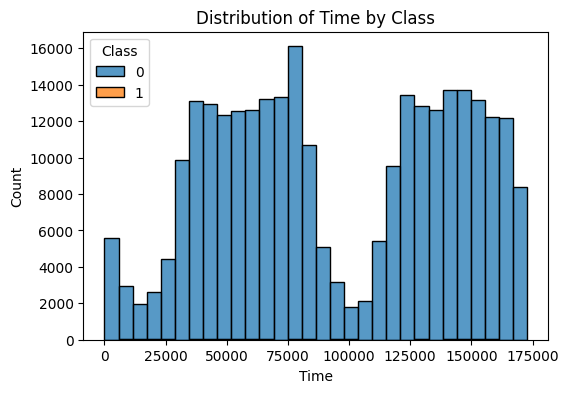

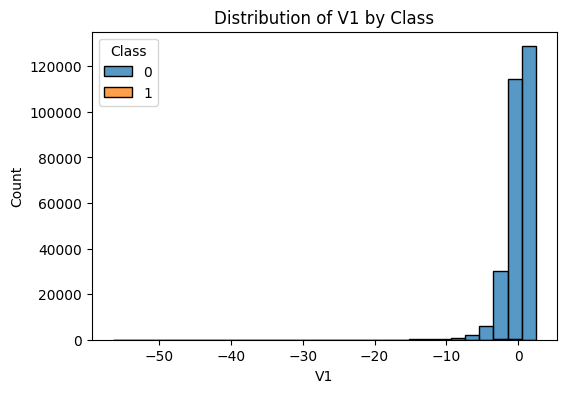

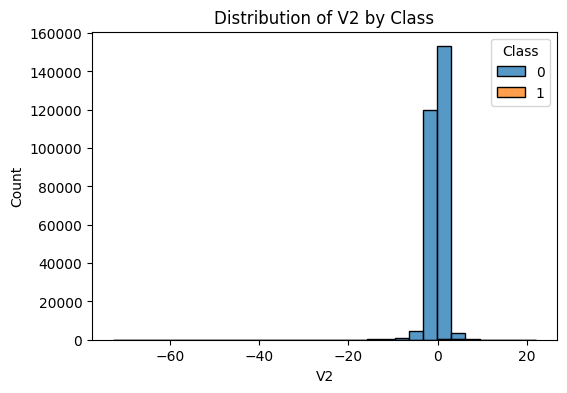

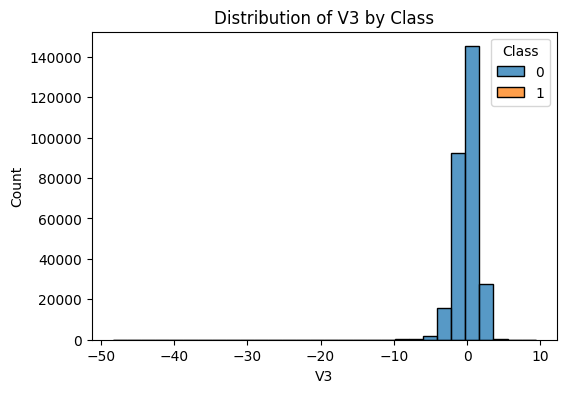

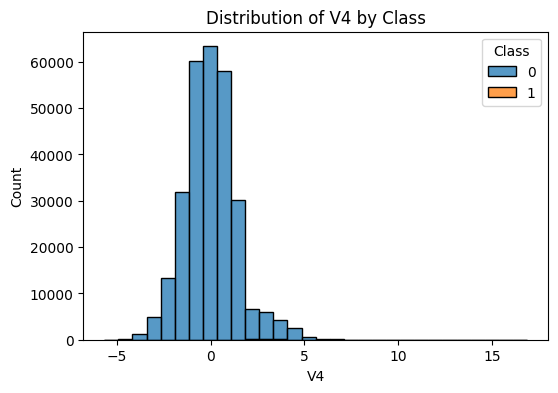

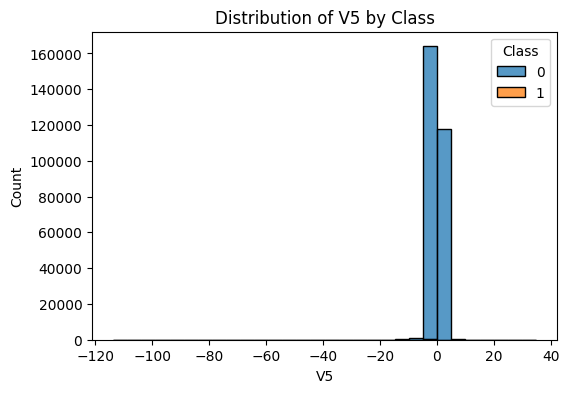

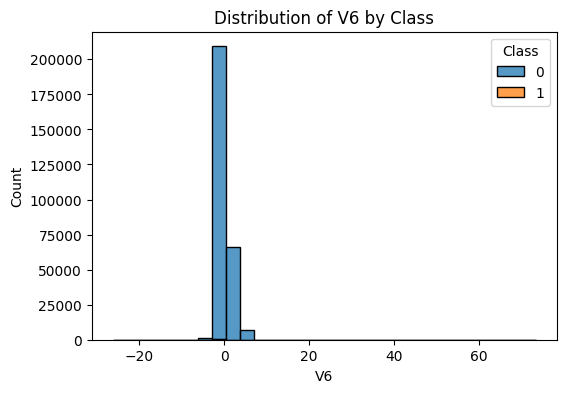

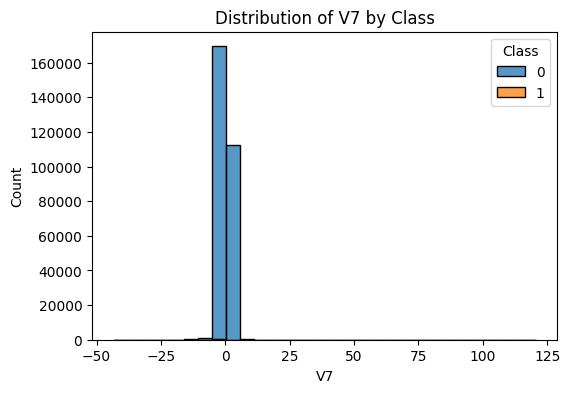

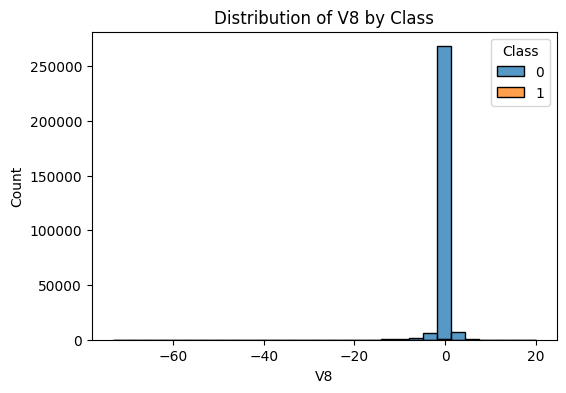

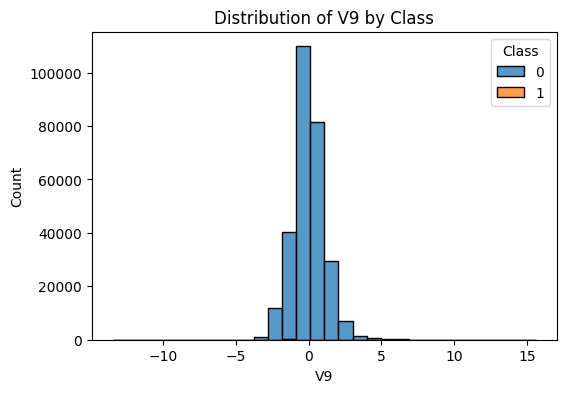

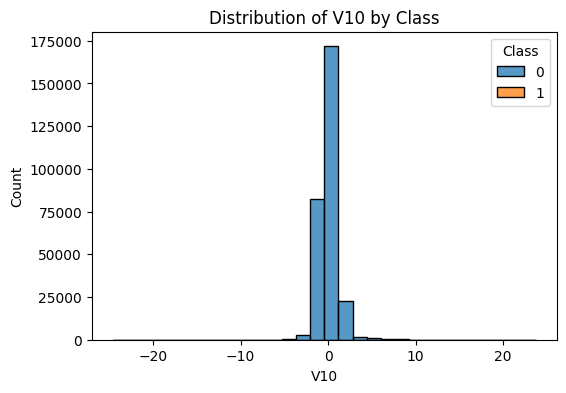

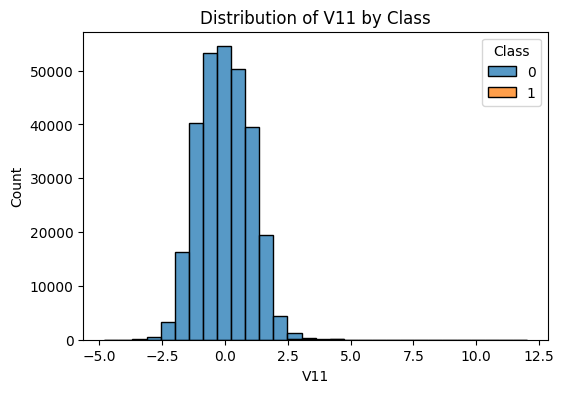

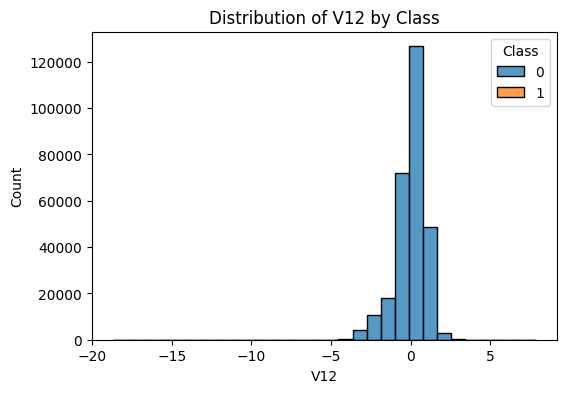

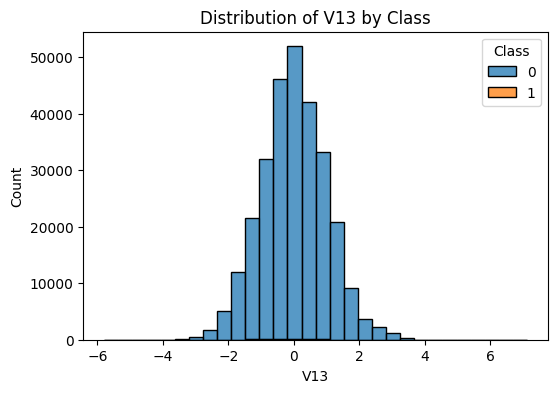

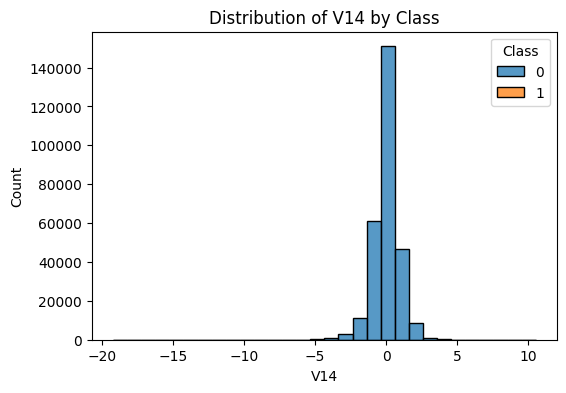

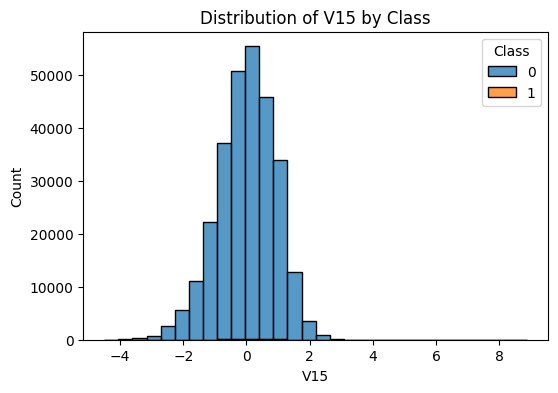

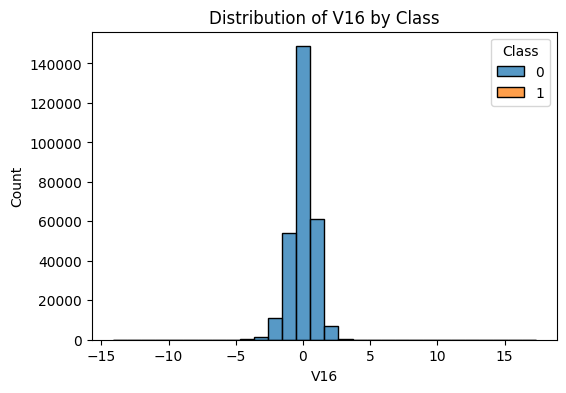

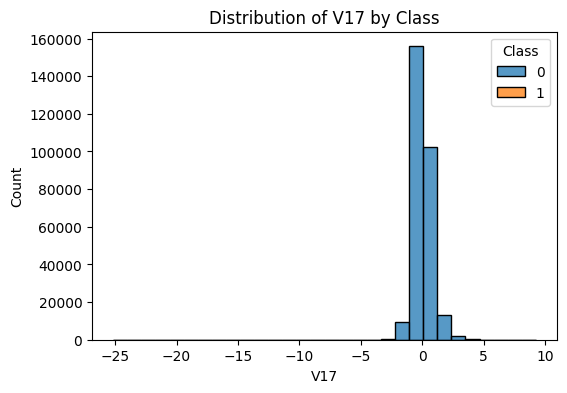

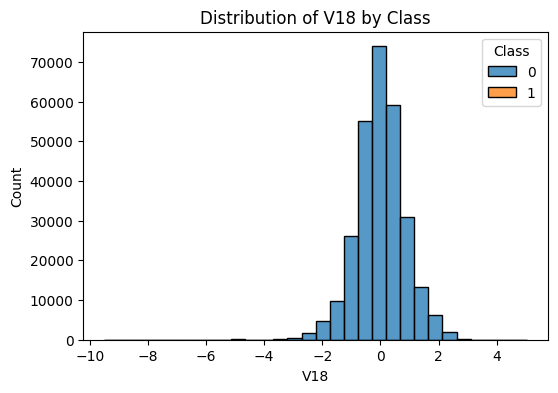

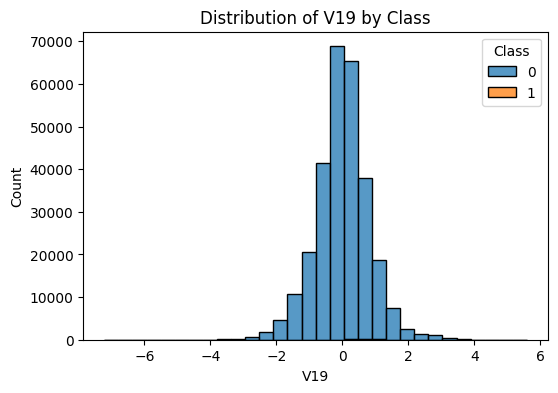

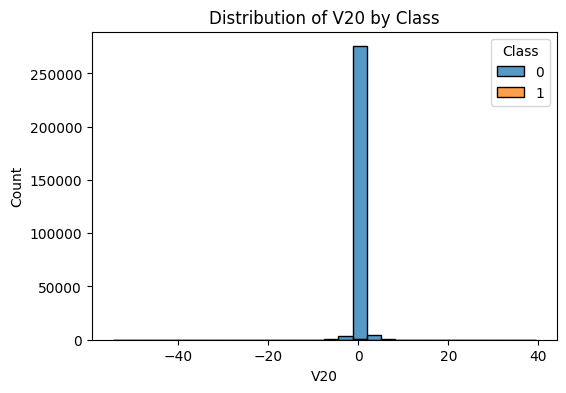

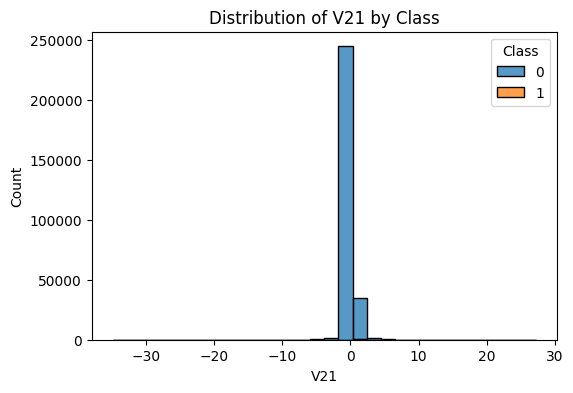

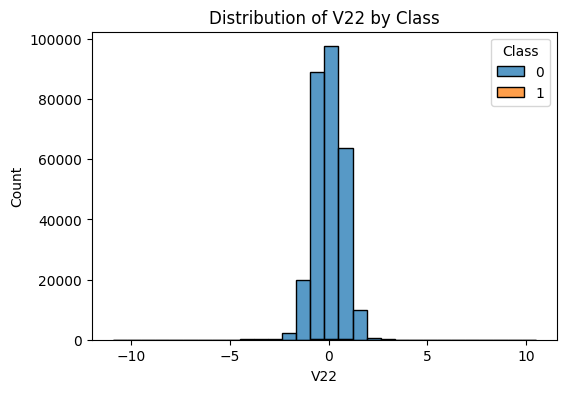

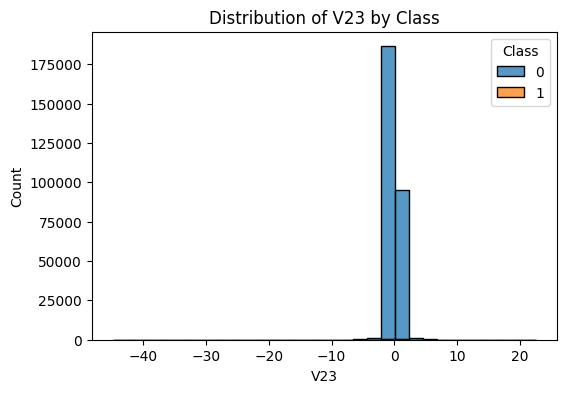

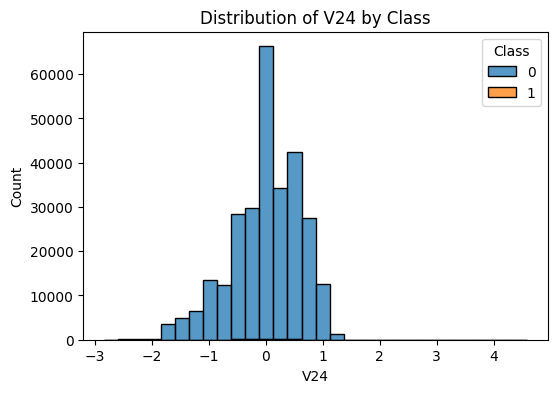

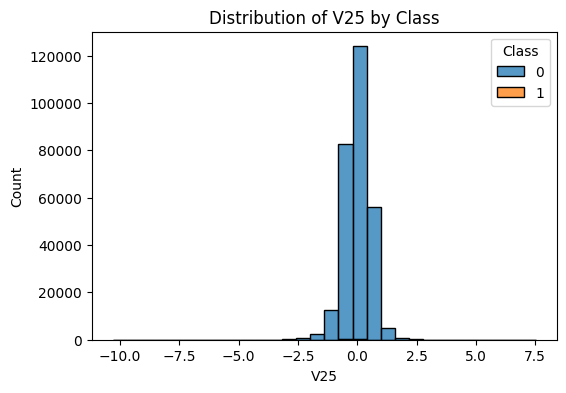

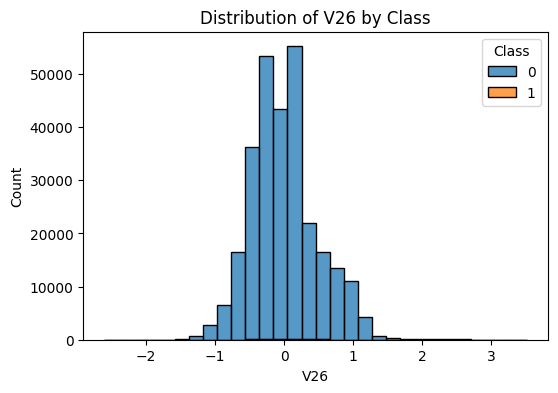

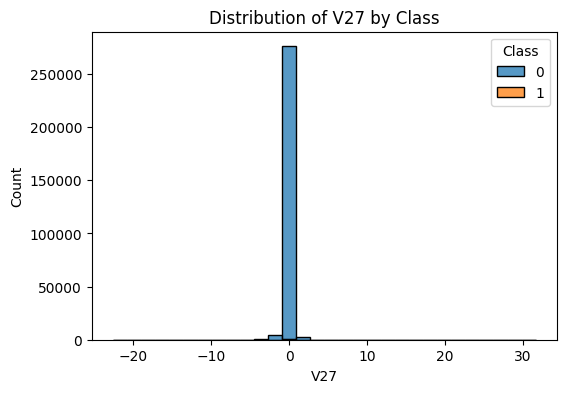

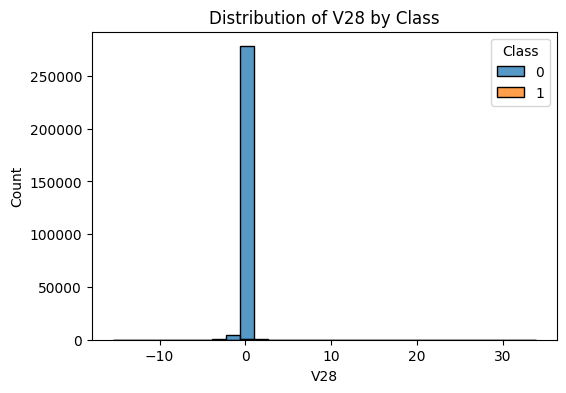

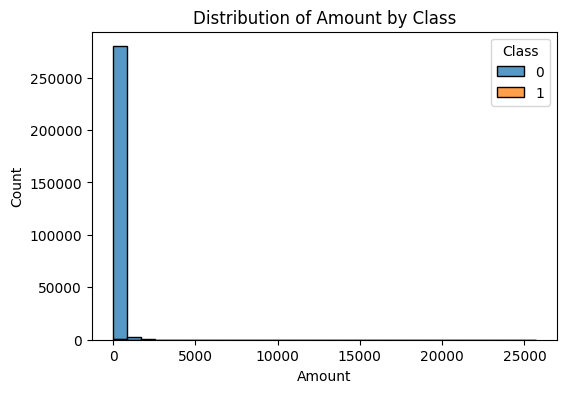

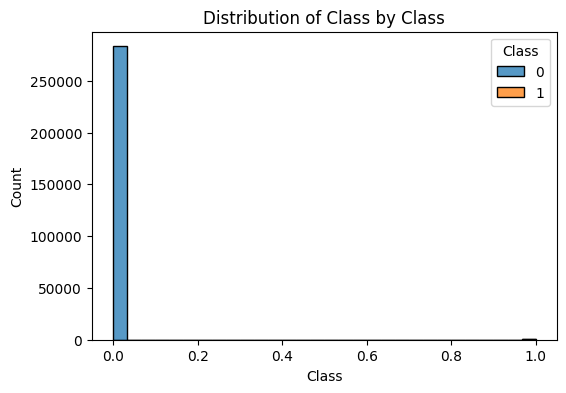

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
print(numeric_cols)
import seaborn as sns


import matplotlib.pyplot as plt


for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='Class', bins=30, kde=False, multiple='stack')
    plt.title(f'Distribution of {col} by Class')
    plt.show()


## Baseline model creation
We are going to train a baseline logistic regression model with no feature selection, SDG with GAN, or cost sensitive learning.

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [ ]:
# Preprocessing for model
scaler = preprocessing.StandardScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Test model on test
y_preds = lr_model.predict(X_test_scaled)
y_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Evaluation metrics
accuracy = metrics.accuracy_score(y_test, y_preds)
recall = metrics.recall_score(y_test, y_preds)
precision = metrics.precision_score(y_test, y_preds)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("Recall: {:.2f}%".format(recall * 100))
print("Precision: {:.2f}%".format(precision * 100))

Accuracy: 99.92%
Recall: 55.79%
Precision: 91.38%


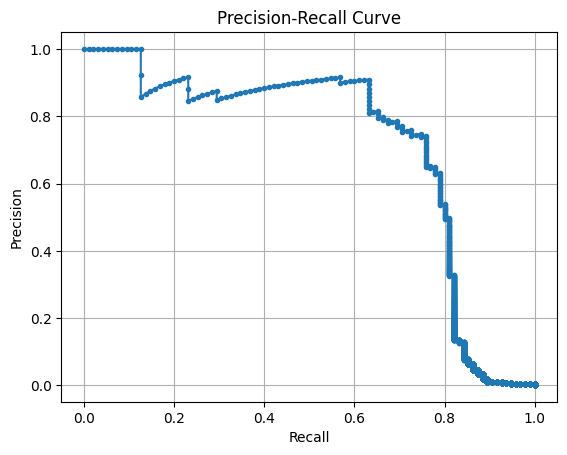

In [ ]:
precision, recall, thresholds = metrics.precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs, pos_label=1)
aucpr = metrics.average_precision_score(y_test, y_probs, pos_label=1)
auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(y_test, y_preds)

print(f"Area under ROC: {auc:.3f}")
print(f"Area under PR: {aucpr:.3f}")
print(f"F1-score: {f1_score:.3f}")


Area under ROC: 0.967
Area under PR: 0.714
F1-score: 0.693


### Findings
To evaluate the model, due to class imbalance we have to consider the recall, area under the Precision-Recall curve, and F1 score.

The baseline logistic regression model has a recall of about 0.5579 (not good, we want to have high recall because cost of a false negative is high, i.e. misclassifying a `TRUE FRAUD` as not fraud is costly.)

The area under the P-R curve is about 0.714, leaving much room for improvement.

The F1 score is mediocre, at 0.694.

## Synthetic Data Generation using conditional GAN
https://www.sciencedirect.com/science/article/pii/S0957417417306346

Use conditional GANs to generate that of minority class.

`dim_z` as defined by the above article is the dimension of the noise. They used random grid search and manual selection to determine `dim_z` but `100` is also a standard value so we will be using `dim_z = 100`.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import keras.backend as K
import time
from tqdm import tqdm

In [ ]:
dim_z = 60
n_labels = 2
labels = [0, 1]
n_features = 30
epoch_count = 50
batch_size = 128

In [ ]:
# Reuse code from baseline model
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

# Preprocessing for model
scaler = preprocessing.StandardScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(buffer_size=len(X)).batch(batch_size)
dataset = dataset.prefetch(tf.data.AUTOTUNE)  # overlaps preprocessing with training

In [ ]:
bce_loss = tf.keras.losses.BinaryCrossentropy()

In [ ]:
# generator and discriminator loss functions
def discriminator_loss(real, fake):
    real_loss = bce_loss(tf.ones_like(real), real)
    fake_loss = bce_loss(tf.zeros_like(fake), fake)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(preds):
    return bce_loss(tf.ones_like(preds), preds)

d_optimizer=Adam(learning_rate=0.001, beta_1 = 0.5)
g_optimizer=Adam(learning_rate=0.001, beta_1 = 0.5)

In [ ]:
def build_generator(latent_dim, data_dim):
    # Inputs
    noise_input = layers.Input(shape=(latent_dim,))
    cond_input = layers.Input(shape=(1,), dtype='int32')  # binary condition

    # Embed condition into a learnable vector
    cond_embedding = layers.Embedding(input_dim=2, output_dim=latent_dim)(cond_input)
    cond_embedding = layers.Flatten()(cond_embedding)

    # Combine noise and condition
    x = layers.Concatenate()([noise_input, cond_embedding])

    # MLP layers
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # Output: continuous features (use 'linear' or 'tanh' depending on your data scaling)
    out = layers.Dense(data_dim, activation='linear')(x)

    return Model([noise_input, cond_input], out, name="Generator")

In [ ]:
def build_discriminator(data_dim):
    data_input = layers.Input(shape=(data_dim,))
    cond_input = layers.Input(shape=(1,), dtype='int32')

    # Embed condition (same as in generator)
    cond_embedding = layers.Embedding(input_dim=2, output_dim=data_dim)(cond_input)
    cond_embedding = layers.Flatten()(cond_embedding)

    # Combine real/generated data with condition embedding
    x = layers.Concatenate()([data_input, cond_embedding])

    # MLP layers
    x = layers.Dense(128)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dense(64)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Output: probability of being real
    out = layers.Dense(1, activation='sigmoid')(x)

    return Model([data_input, cond_input], out, name="Discriminator")


In [ ]:
generator = build_generator(dim_z, n_features)
discriminator = build_discriminator(n_features)

generator.summary()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 1, 60)     │        120 │ input_layer_27[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_26      │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 60)        │          0 │ embedding_13[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 120)       │          0 │ input_layer_26[0… │
│ (Concatenate)       │                   │            │ flatten_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 128)       │     15,488 │ concatenate_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_47[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 128)       │     16,512 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_48[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 30)        │      3,870 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,014 (144.59 KB)

 Trainable params: 36,502 (142.59 KB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_14        │ (None, 1, 30)     │         60 │ input_layer_29[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_28      │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 30)        │          0 │ embedding_14[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 60)        │          0 │ input_layer_28[0… │
│ (Concatenate)       │                   │            │ flatten_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 128)       │      7,808 │ concatenate_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_28      │ (None, 128)       │          0 │ dense_50[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 64)        │      8,256 │ leaky_re_lu_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_29      │ (None, 64)        │          0 │ dense_51[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 1)         │         65 │ leaky_re_lu_29[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,189 (63.24 KB)

 Trainable params: 16,189 (63.24 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
@tf.function
def train_step(real_data, cond_labels):
    batch_size = tf.shape(real_data)[0]
    noise = tf.random.normal([batch_size, dim_z])

    # Generate fake data
    fake_data = generator([noise, cond_labels], training=True)

    # Train discriminator
    with tf.GradientTape() as d_tape:
        real_preds = discriminator([real_data, cond_labels], training=True)
        fake_preds = discriminator([fake_data, cond_labels], training=True)
        d_loss = discriminator_loss(real_preds, fake_preds)

    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # Train generator
    noise = tf.random.normal([batch_size, dim_z])
    with tf.GradientTape() as g_tape:
        fake_data = generator([noise, cond_labels], training=True)
        fake_preds = discriminator([fake_data, cond_labels], training=True)
        g_loss = generator_loss(fake_preds)

    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    return d_loss, g_loss


In [ ]:
@tf.function
def train_epoch(dataset):
  d_loss = tf.constant(0.0)
  g_loss = tf.constant(0.0)

  for real_data, cond_labels in dataset:
      d_loss, g_loss = train_step(real_data, cond_labels)
  return d_loss, g_loss

In [ ]:
for epoch in range(epoch_count):
  d_loss, g_loss = train_epoch(dataset)
  print(f"Epoch {epoch+1}/{epoch_count} | D loss: {d_loss:.4f} | G loss: {g_loss:.4f}")

Epoch 1/50 | D loss: 0.0007 | G loss: 8.1155
Epoch 2/50 | D loss: 0.0026 | G loss: 7.0363
Epoch 3/50 | D loss: 0.1440 | G loss: 7.4622
Epoch 4/50 | D loss: 0.0000 | G loss: 57.7940
Epoch 5/50 | D loss: 0.0066 | G loss: 6.0130
Epoch 6/50 | D loss: 0.0430 | G loss: 5.3412
Epoch 7/50 | D loss: 0.1768 | G loss: 6.1530
Epoch 8/50 | D loss: 0.0023 | G loss: 8.3396
Epoch 9/50 | D loss: 0.0079 | G loss: 6.0101
Epoch 10/50 | D loss: 0.1011 | G loss: 5.2466
Epoch 11/50 | D loss: 0.1484 | G loss: 4.1183
Epoch 12/50 | D loss: 0.0047 | G loss: 5.6641
Epoch 13/50 | D loss: 0.0170 | G loss: 5.6422
Epoch 14/50 | D loss: 0.0906 | G loss: 4.1163
Epoch 15/50 | D loss: 0.3051 | G loss: 3.2096
Epoch 16/50 | D loss: 0.0408 | G loss: 5.5834
Epoch 17/50 | D loss: 0.1838 | G loss: 4.8007
Epoch 18/50 | D loss: 0.1122 | G loss: 4.4336
Epoch 19/50 | D loss: 0.2238 | G loss: 2.7537
Epoch 20/50 | D loss: 0.2125 | G loss: 4.0769
Epoch 21/50 | D loss: 0.0419 | G loss: 4.5590
Epoch 22/50 | D loss: 0.1934 | G loss: 4.2

In [ ]:
# Save weights
#generator.save_weights("generator_weights.weights.h5")

# download weights
from google.colab import files
#files.download('generator_weights.weights.h5')

#to upload weights
uploaded = files.upload()




Saving generator_weights.weights.h5 to generator_weights.weights.h5
Saving real_and_sdg.csv to real_and_sdg.csv


In [ ]:
# Later, rebuild model architecture
generator = build_generator(dim_z, n_features)
generator.load_weights("generator_weights.weights.h5")

combined_data = pd.read_csv("real_and_sdg.csv")
# available model architectures
# generator_weights.weights.h5
# have to upload the generator weights file again

In [ ]:
# Number of samples to generate
num_samples = 4000

# Condition you want to generate (0 or 1)
cond_value = 1

# Sample random noise
noise = tf.random.normal([num_samples, dim_z])

# Create condition labels
cond_labels = tf.constant([[cond_value]] * num_samples, dtype=tf.int32)

# Generate synthetic data
generated_data = generator([noise, cond_labels], training=False)

# Convert to numpy for easy use
generated_data = generated_data.numpy()
print(generated_data.shape)  # (1000, data_dim)

(4000, 30)


In [ ]:
generated_data = pd.DataFrame(generated_data, columns=X.columns)
generated_data["Class"] = cond_value

In [ ]:
generated_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,28458.457031,7.330498,-12.644435,3.828314,20.104980,22.817787,-4.573620,11.035233,7.500995,-21.332994,...,-8.555633,24.320253,0.378365,4.093127,-31.005632,3.375837,0.058534,-6.653195,898.190125,1
1,17100.273438,9.800060,-11.473445,3.104200,18.812502,23.979773,-3.907983,12.393256,9.695983,-21.957619,...,-9.454180,25.288534,1.983677,4.777853,-32.635593,5.501554,-1.111959,-7.958116,872.363831,1
2,28585.333984,7.069782,-12.367281,3.682205,19.670038,23.767897,-4.902070,10.963428,7.739892,-22.325457,...,-8.271930,24.396013,0.441322,3.979384,-31.989426,3.676120,0.128349,-6.727230,895.487244,1
3,30431.941406,4.106631,-12.310632,5.142936,20.436817,18.702358,-3.030795,8.150617,6.264256,-20.725195,...,-6.346656,22.006874,-0.591075,3.828470,-26.663960,1.590168,-0.034248,-6.676438,887.812683,1
4,37602.085938,-6.835695,-11.182507,9.584231,21.410931,4.359611,1.731611,-1.662526,1.171753,-18.995129,...,1.977288,14.053942,-4.462260,2.632488,-12.153405,-4.935329,0.367417,-6.893933,849.569092,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,35065.203125,-2.899955,-11.592402,7.936213,20.913132,10.037491,-0.090904,2.043664,3.072690,-20.166578,...,-0.929475,17.166401,-3.137338,3.061246,-18.145952,-2.473822,0.325177,-6.966527,864.166382,1
3996,49243.527344,-14.515199,3.343042,5.898116,6.651707,15.239504,5.986676,-11.850835,1.465277,-19.464329,...,14.398507,2.275848,-0.841680,-1.938100,-9.859728,5.131808,-5.546353,12.580008,821.489258,1
3997,29253.150391,6.046782,-12.483927,4.239022,20.062408,21.843197,-4.338520,9.771830,7.123181,-21.242329,...,-7.653757,23.715340,0.059209,4.124502,-29.407309,2.874548,-0.136955,-6.679157,900.044373,1
3998,33305.687500,-0.449422,-11.838744,6.844435,20.987221,12.785492,-1.276975,4.027585,4.131611,-20.066301,...,-2.906743,18.926020,-2.124478,3.277372,-20.687250,-1.238341,0.210187,-6.966074,876.978943,1


In [ ]:
# Check distribution of real and fake data
real_data_pos = df.loc[df["Class"] == 1]
fake_data = generated_data.copy()


### SDG GAN Result Evaluation

First we check the distribution of the real data vs the synthetic data. They should have a similar shape

In [ ]:
# Get rid of negative amounts
fake_data = fake_data.loc[fake_data["Amount"] > 0]

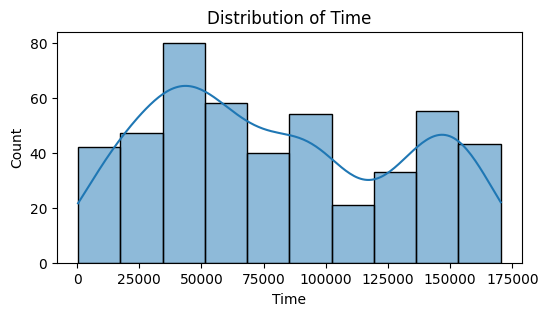

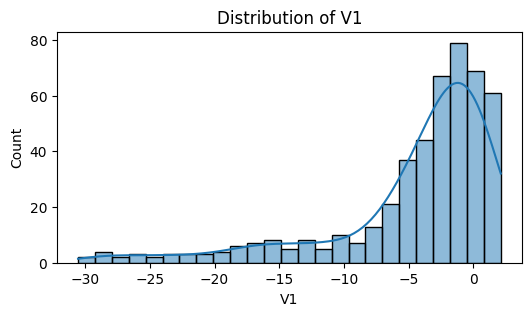

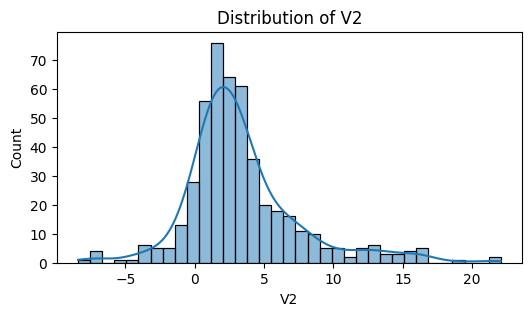

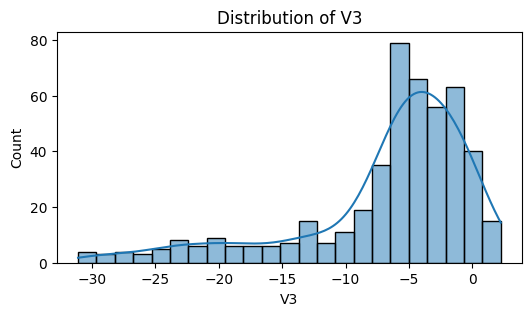

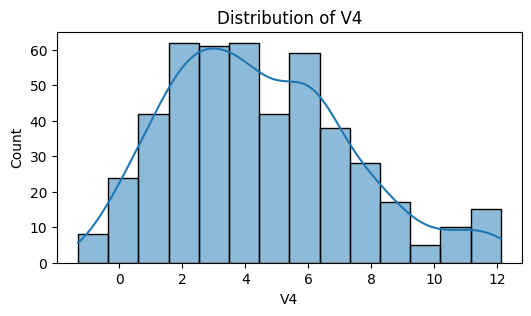

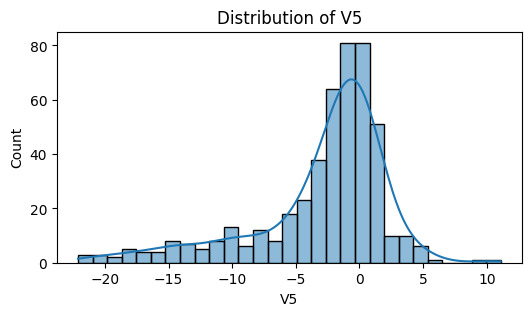

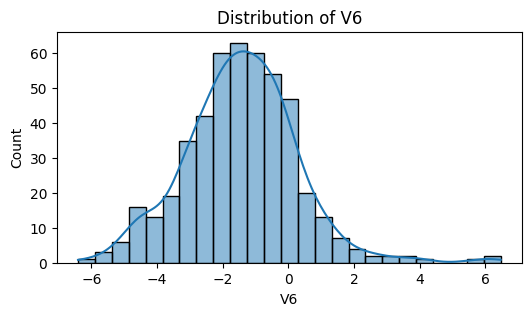

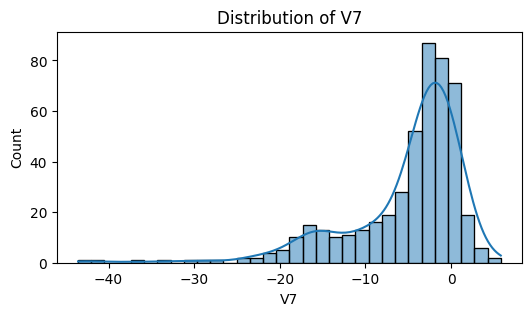

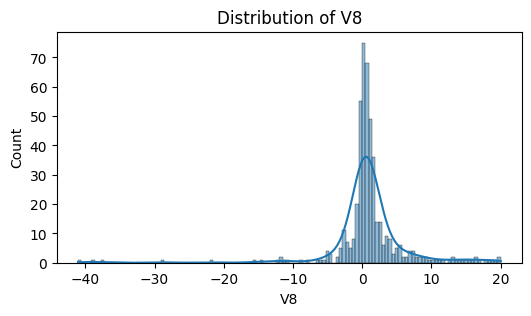

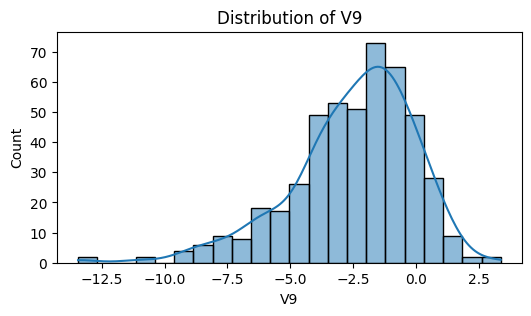

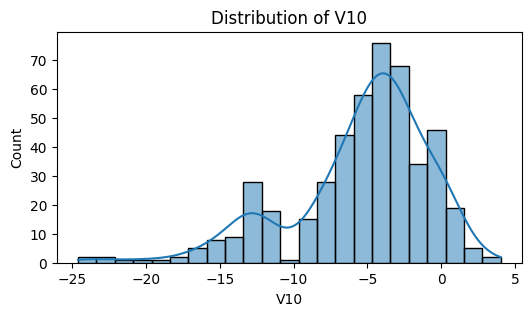

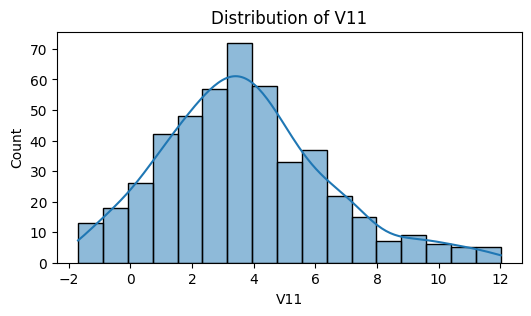

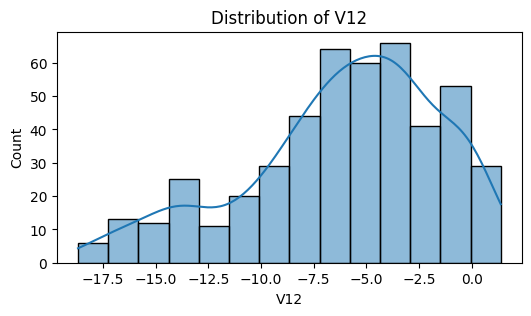

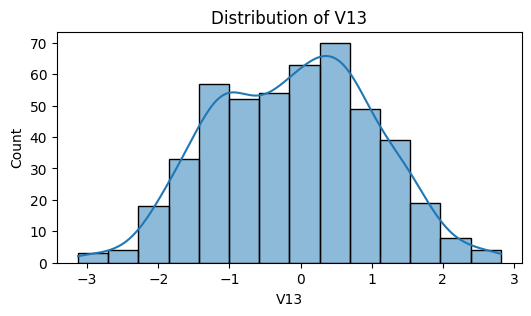

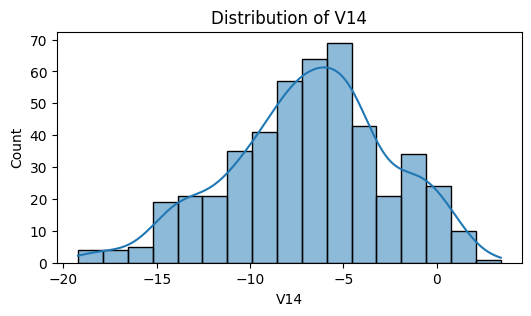

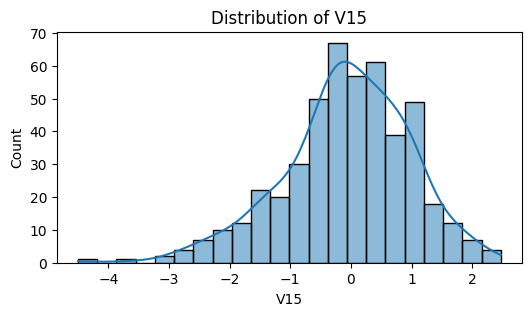

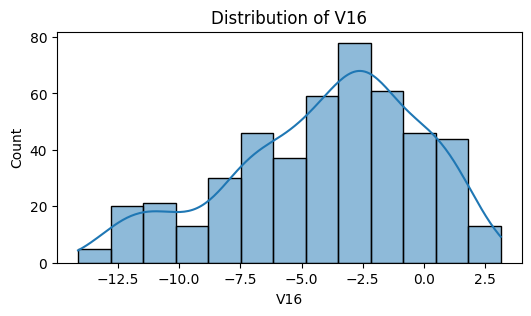

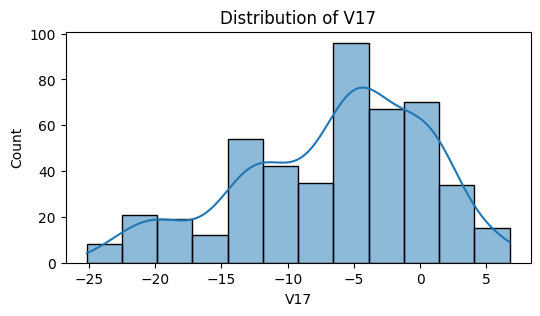

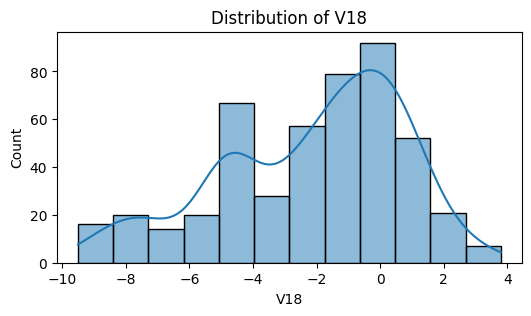

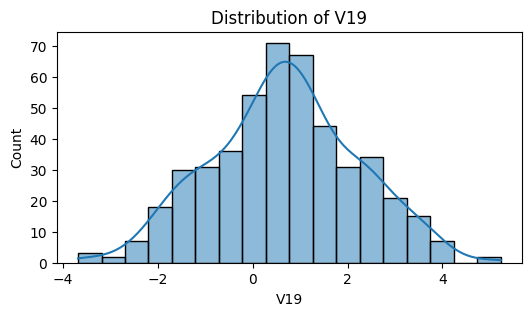

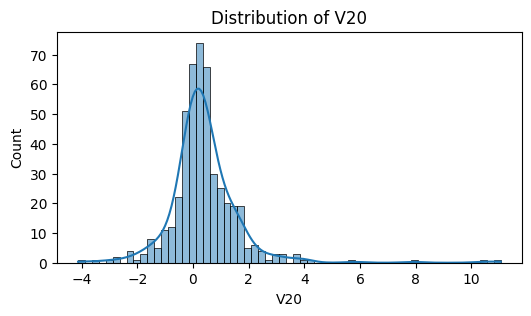

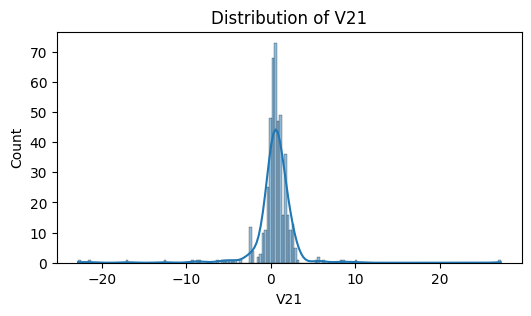

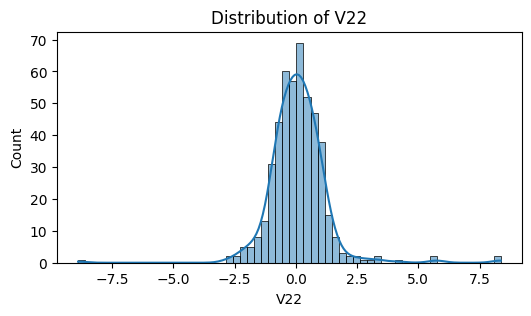

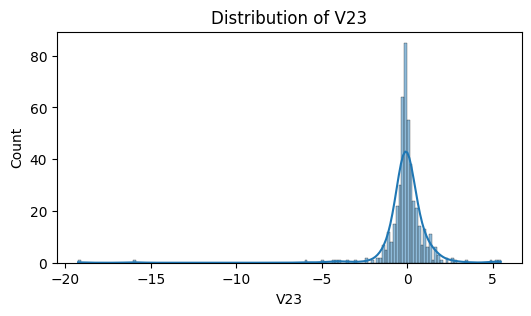

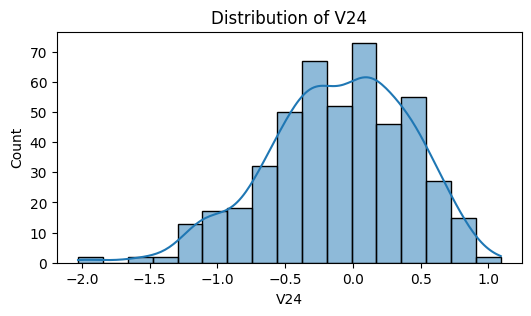

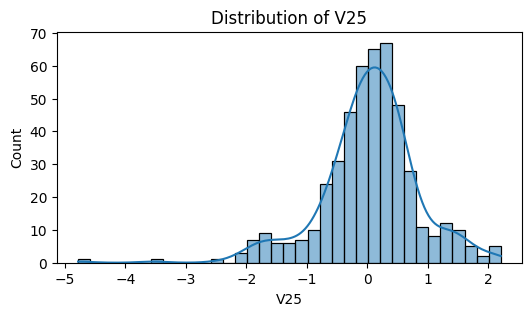

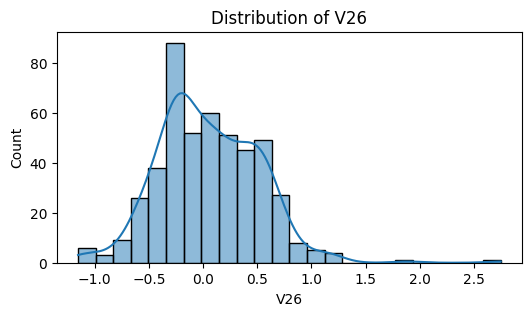

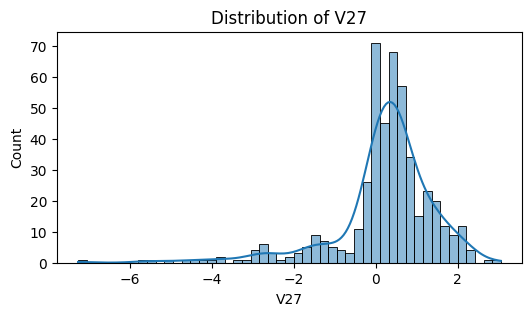

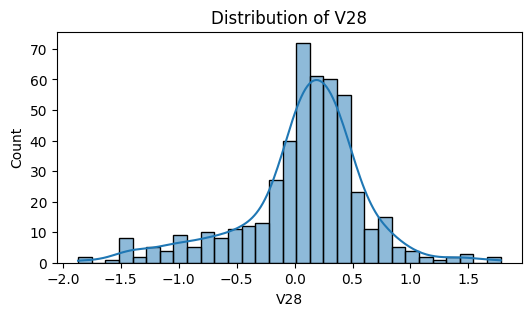

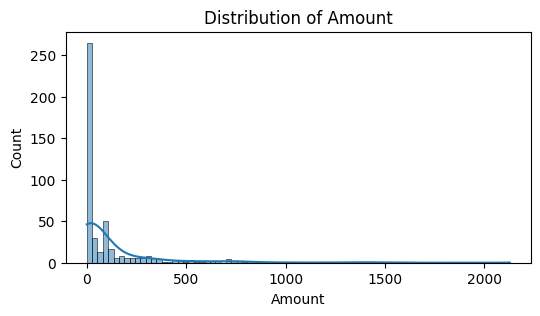

In [ ]:
# Real data
col_names = real_data_pos.columns[:-1] # all columns but target
for col in col_names:
    plt.figure(figsize=(6, 3))
    sns.histplot(real_data_pos[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

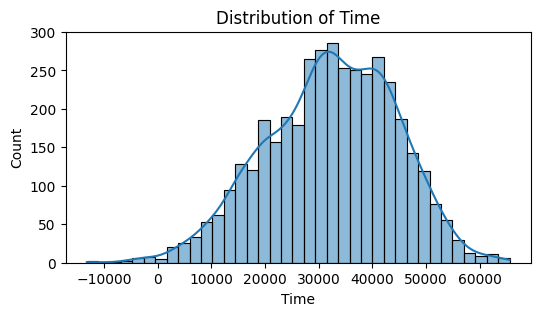

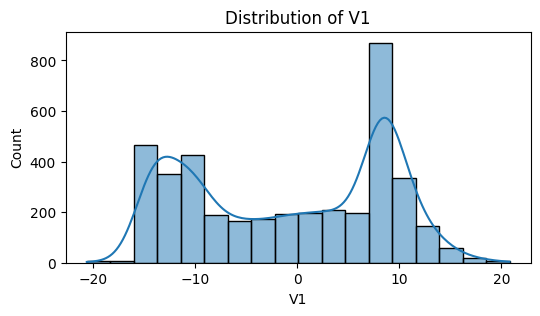

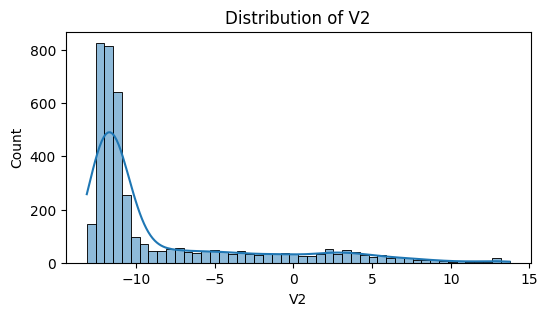

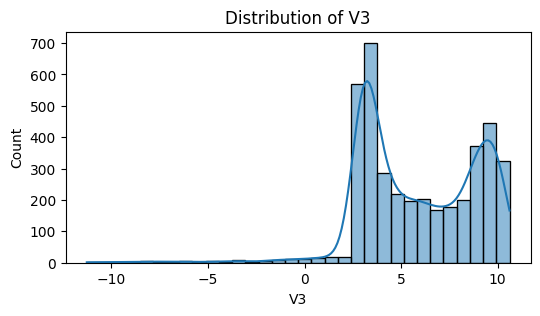

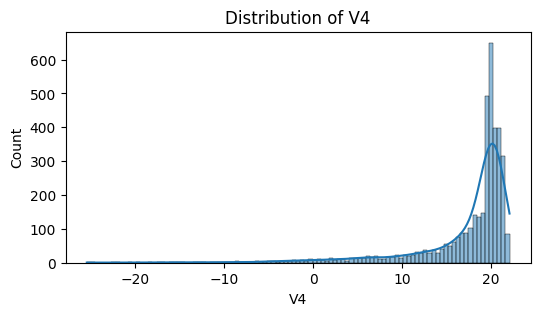

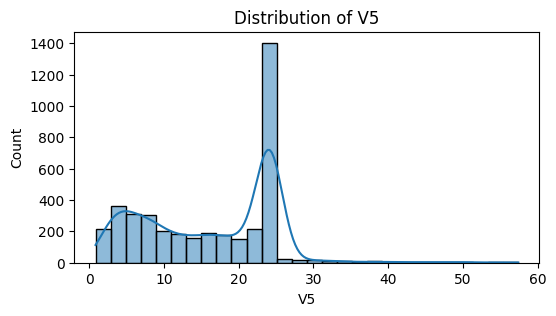

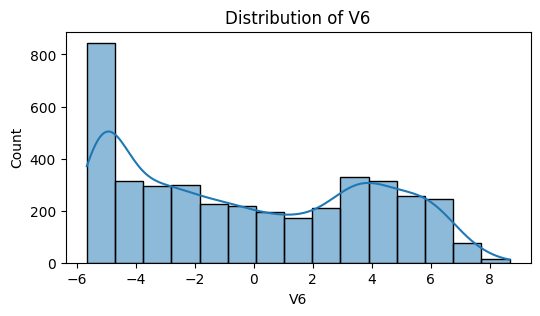

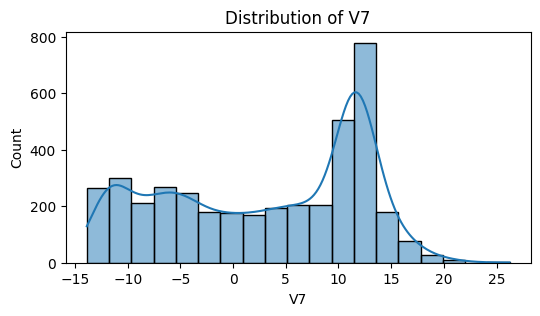

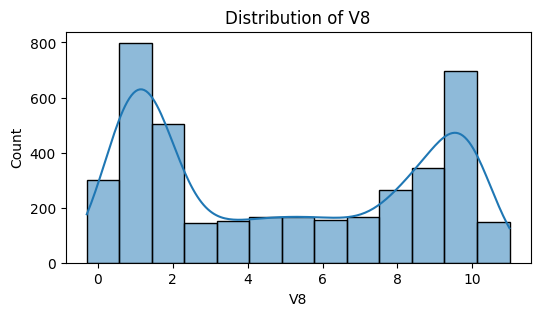

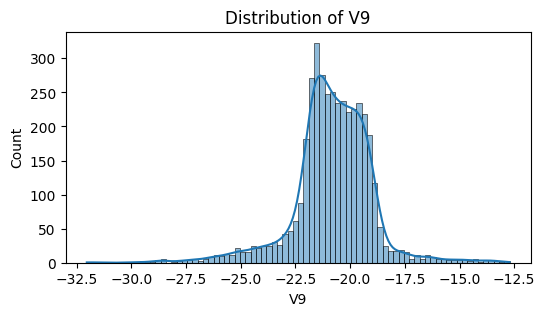

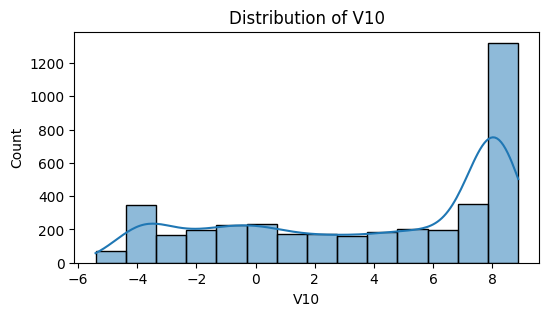

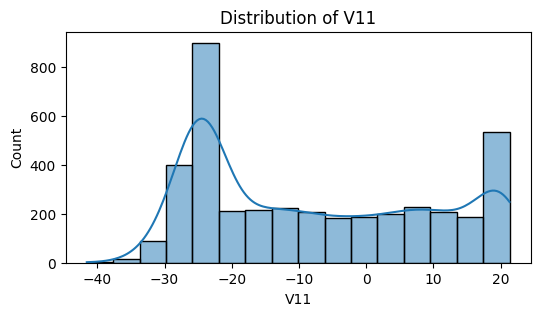

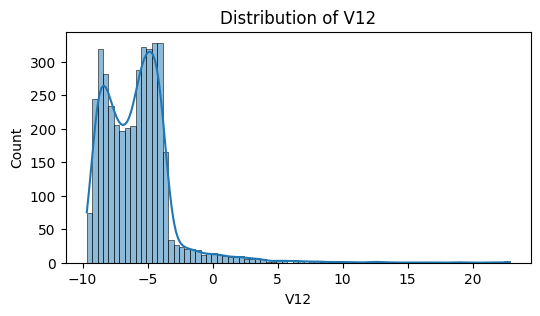

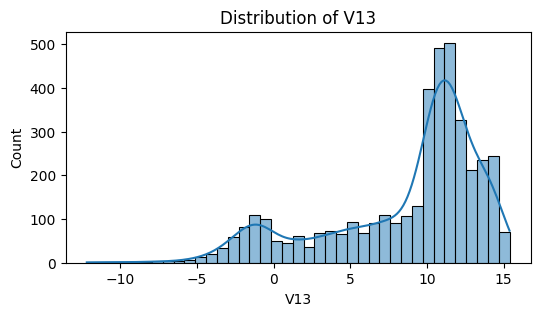

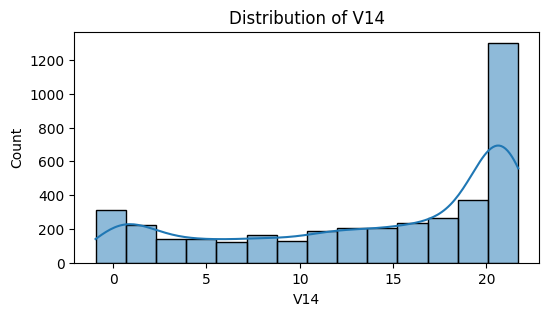

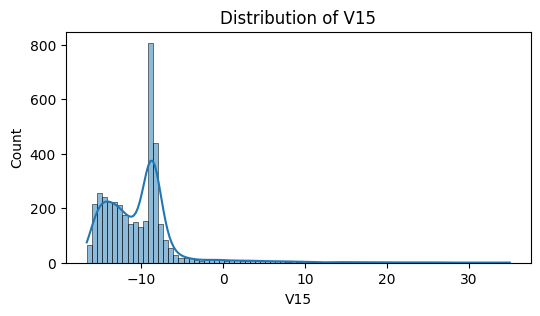

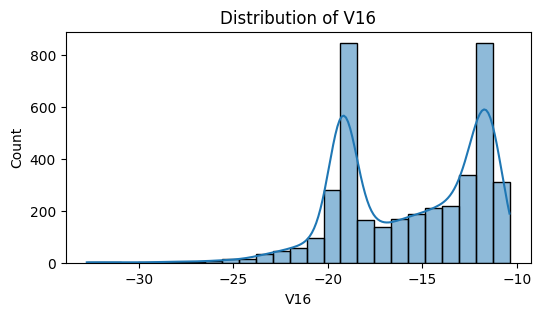

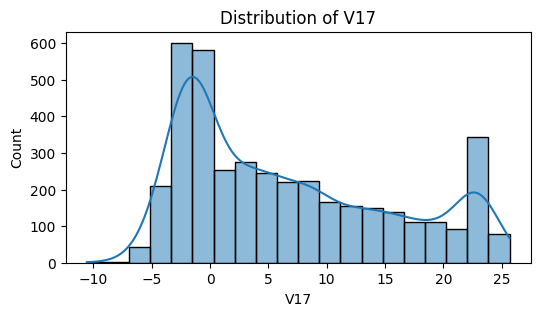

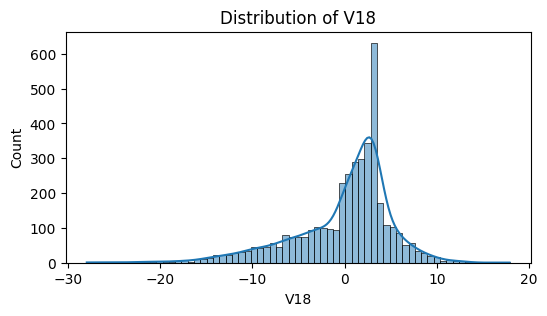

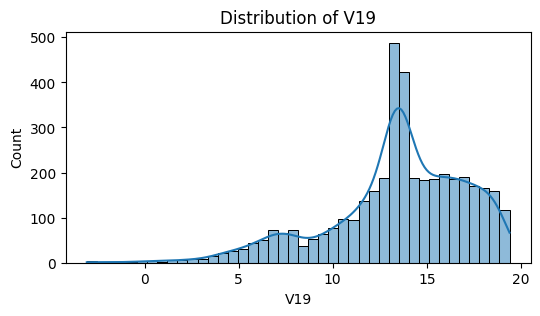

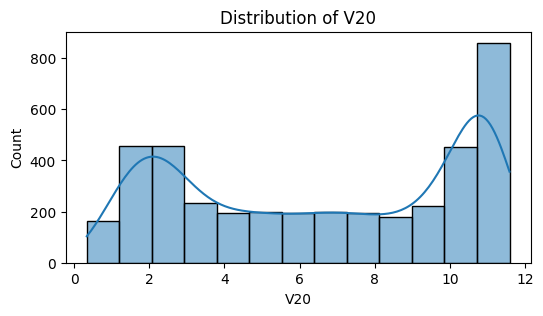

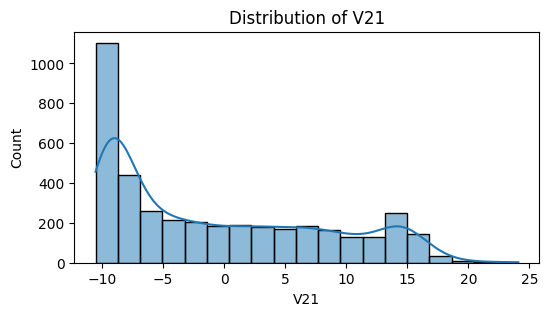

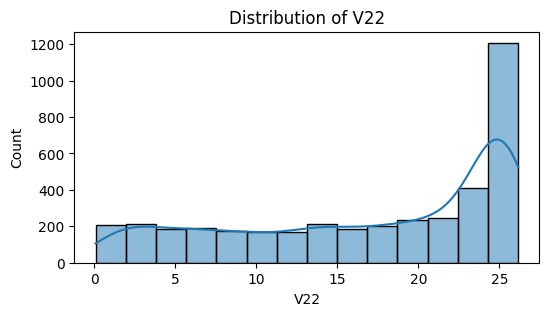

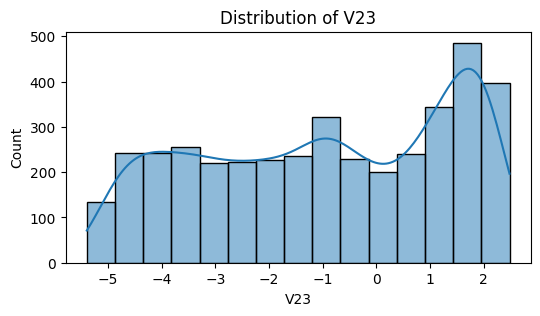

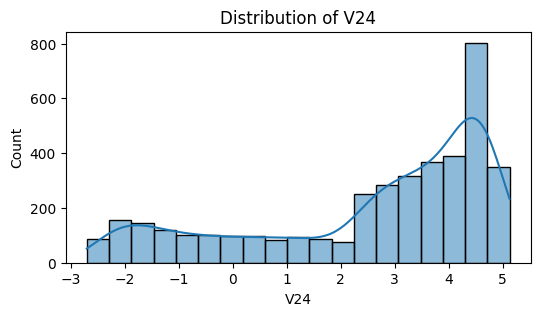

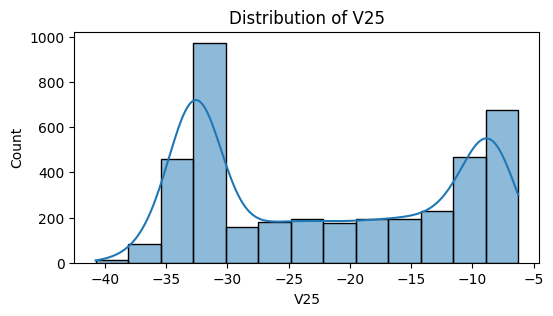

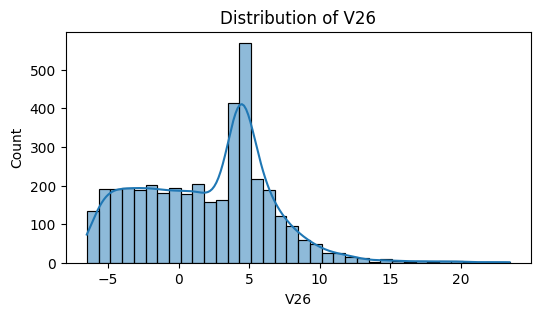

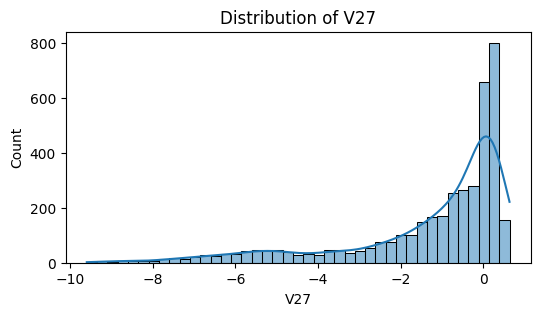

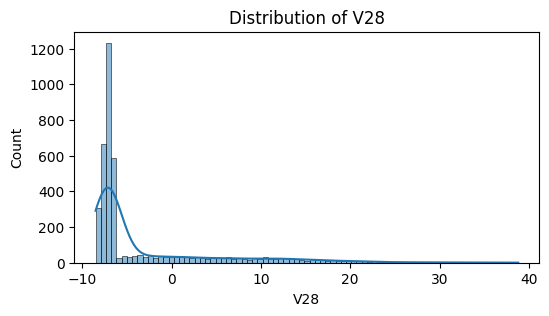

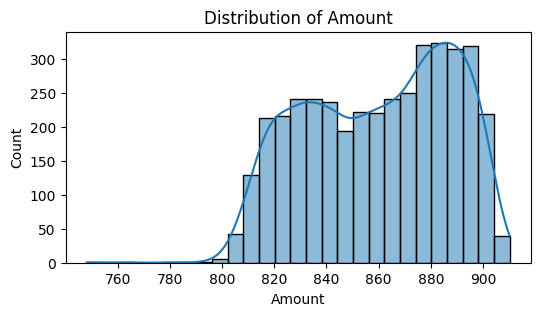

In [ ]:
# Fake data
col_names = fake_data.columns[:-1] # all columns but target
for col in col_names:
    plt.figure(figsize=(6, 3))
    sns.histplot(fake_data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Model training after SDG GAN step

Now we train another logistic regression model, but with the real and fake data mixed together.

In [ ]:
combined_data = pd.concat([fake_data, df])
combined_data.shape # verify that they have been added correctly

# save as csv
# combined_data.to_csv("real_and_sdg.csv", index = False)

(285726, 31)

In [ ]:
X_sdg = combined_data.drop("Class", axis=1)
y_sdg = combined_data["Class"]

X_train_sdg, X_test_sdg, y_train_sdg, y_test_sdg = train_test_split(X_sdg, y_sdg, test_size=0.3, stratify=y_sdg, random_state=1)

# Preprocessing for model
scaler_sdg = preprocessing.StandardScaler().fit(X_train_sdg)

X_train_scaled_sdg = scaler_sdg.transform(X_train_sdg)
X_test_scaled_sdg = scaler_sdg.transform(X_test_sdg)

# Train model
lr_model_sdg = LogisticRegression()
lr_model_sdg.fit(X_train_scaled_sdg, y_train_sdg)

# Test model on test
y_preds_sdg = lr_model_sdg.predict(X_test_scaled_sdg)
y_probs_sdg = lr_model_sdg.predict_proba(X_test_scaled_sdg)[:, 1]

In [ ]:
# Evaluation metrics
accuracy = metrics.accuracy_score(y_test_sdg, y_preds_sdg)
recall = metrics.recall_score(y_test_sdg, y_preds_sdg)
precision = metrics.precision_score(y_test_sdg, y_preds_sdg)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("Recall: {:.2f}%".format(recall * 100))
print("Precision: {:.2f}%".format(precision * 100))

fpr, tpr, thresholds = metrics.roc_curve(y_test_sdg, y_probs_sdg, pos_label=1)
aucpr = metrics.average_precision_score(y_test_sdg, y_probs_sdg, pos_label=1)
auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(y_test_sdg, y_preds_sdg)

print(f"Area under ROC: {auc:.3f}")
print(f"Area under PR: {aucpr:.3f}")
print(f"F1-score: {f1_score:.3f}")


Accuracy: 99.92%
Recall: 91.91%
Precision: 98.55%
Area under ROC: 0.997
Area under PR: 0.975
F1-score: 0.951


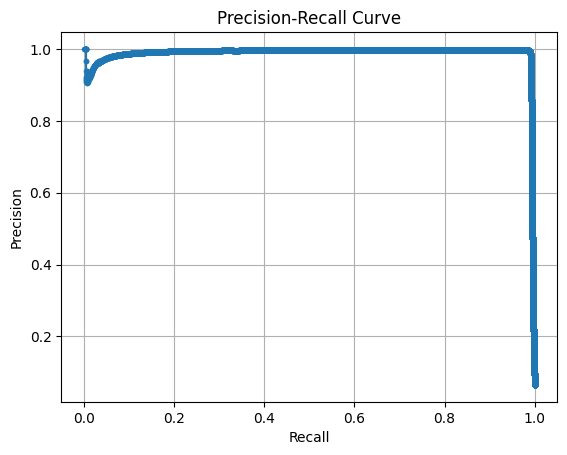

In [ ]:
precision, recall, thresholds = metrics.precision_recall_curve(y_test_sdg, y_probs_sdg)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

## Cost sensitive learning
Now we try cost sensitive learning by considering the total cost of misclassifying every `TRUE FRAUD` as not fraud.

The total cost would be the sum of the `Amount` column for `class=1`.

In [ ]:
combined_data['Amount'] = combined_data["Amount"].apply(np.log1p)

In [ ]:
combined_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,3570.937012,-0.337203,0.077323,1.693609,3.175164,-0.912068,-0.364733,-0.304674,0.428258,1.766845,...,-1.421696,0.685302,1.022689,-0.120698,0.114446,-0.225216,-0.499706,-0.404962,3.394440,1
1,3986.463623,-0.422926,0.361584,1.617804,3.158456,-0.251843,-0.077731,-0.259335,0.353250,1.557829,...,-1.310543,0.489327,1.137920,0.194334,0.273119,-0.830945,-0.422839,-0.275746,2.658597,1
2,7392.643066,-0.220197,1.133809,2.519842,3.510712,-0.129401,-0.113938,-0.354641,0.631734,1.380537,...,-1.285448,1.118189,2.177959,-0.010209,0.555267,-0.808078,-0.417551,-1.152198,3.538032,1
3,830.667908,-0.090726,-0.534268,0.660718,2.586988,-0.374141,0.257448,0.099462,1.155642,0.743027,...,-1.125656,0.373714,-0.008730,-0.001673,-0.752095,-0.098064,0.216227,-0.071169,3.872532,1
4,4730.003418,-0.141943,-0.437709,1.863636,3.731928,-1.912291,0.376972,-0.468468,0.518923,2.159204,...,-1.598365,1.826981,1.742301,-0.535078,0.339236,0.020707,-0.339765,-0.916807,4.882532,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283721,172786.000000,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.570980,0
283722,172787.000000,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,3.249987,0
283723,172788.000000,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,4.232366,0
283724,172788.000000,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,2.397895,0


In [ ]:
X_sdg_cost = combined_data.drop("Class", axis=1)
y_sdg_cost = combined_data["Class"]

X_train_sdg_cost, X_test_sdg_cost, y_train_sdg_cost, y_test_sdg_cost = train_test_split(X_sdg_cost, y_sdg_cost, test_size=0.3, stratify=y_sdg_cost, random_state=50)
w_cost = X_train_sdg_cost["Amount"]

# Preprocessing for model
scaler_sdg_cost = preprocessing.StandardScaler().fit(X_train_sdg_cost)

X_train_scaled_sdg_cost = scaler_sdg_cost.transform(X_train_sdg_cost)
X_test_scaled_sdg_cost = scaler_sdg_cost.transform(X_test_sdg_cost)

# Train model
lr_model_sdg_cost = LogisticRegression()
lr_model_sdg_cost.fit(X_train_scaled_sdg_cost, y_train_sdg_cost, sample_weight=w_cost)

# Test model on test
y_preds_sdg_cost = lr_model_sdg_cost.predict(X_test_scaled_sdg_cost)
y_probs_sdg_cost = lr_model_sdg_cost.predict_proba(X_test_scaled_sdg_cost)[:, 1]

In [ ]:
# Evaluation metrics
accuracy = metrics.accuracy_score(y_test_sdg_cost, y_preds_sdg_cost)
recall = metrics.recall_score(y_test_sdg_cost, y_preds_sdg_cost)
precision = metrics.precision_score(y_test_sdg_cost, y_preds_sdg_cost)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("Recall: {:.2f}%".format(recall * 100))
print("Precision: {:.2f}%".format(precision * 100))

fpr, tpr, thresholds = metrics.roc_curve(y_test_sdg_cost, y_probs_sdg_cost, pos_label=1)
aucpr = metrics.average_precision_score(y_test_sdg_cost, y_probs_sdg_cost, pos_label=1)
auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(y_test_sdg_cost, y_preds_sdg_cost)

print(f"Area under ROC: {auc:.3f}")
print(f"Area under PR: {aucpr:.3f}")
print(f"F1-score: {f1_score:.3f}")


Accuracy: 99.88%
Recall: 98.72%
Precision: 99.39%
Area under ROC: 0.996
Area under PR: 0.985
F1-score: 0.991


In [ ]:
combined_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,8254.242188,-6.786524,0.920280,3.773640,5.524253,-2.372242,23.100100,-1.128142,6.209849,-1.515919,...,-6.618046,12.973137,-4.602851,3.943491,6.982092,-6.164233,-4.176124,11.848075,733.077698,1
1,10235.333008,-3.909676,1.790764,2.225029,2.964610,-2.968734,16.858040,-0.541093,5.928333,0.177035,...,-5.513890,10.493412,-2.883288,2.572271,6.412002,-4.733414,-3.757676,9.017237,551.285461,1
2,3541.678711,-0.929493,1.230841,-2.097272,2.180370,-3.957496,9.386420,-3.267411,5.693679,-0.019883,...,-2.534765,4.883546,-3.493193,3.023960,5.785523,-4.651976,-4.036564,4.750628,347.959686,1
3,7818.148438,-8.441978,0.496021,4.966617,6.807808,-1.982065,26.795935,-1.146208,6.284964,-2.355987,...,-7.345420,14.662518,-5.333006,4.569836,7.314795,-6.899902,-4.398734,13.580909,836.455383,1
4,1261.023560,-5.981399,0.580873,1.441590,5.470459,-2.010710,20.860767,-4.559735,6.510121,-2.424106,...,-4.474145,9.747669,-5.564567,4.797857,6.353221,-6.646878,-4.386290,8.918626,641.149414,1


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
189,-1506.796509,-11.280613,-7.892894,-4.932752,28.835018,-8.469909,24.196001,-1.303204,6.815300,-0.364332,...,-19.470890,19.948160,-13.610907,10.821508,11.848683,-8.992008,-5.891713,26.254353,1490.234375,1
1606,-6267.784668,-7.277673,-2.274422,-3.634541,36.163231,-4.697910,34.448757,-13.451387,7.242568,-2.934626,...,-20.989988,22.310837,-11.093488,8.616587,13.900446,-8.861058,-2.668209,33.718826,1738.967163,1
1856,-2128.872314,-10.562758,-7.421032,-5.470412,31.413372,-7.992682,24.844294,-3.226743,6.901594,0.070172,...,-20.907738,20.995258,-13.136827,10.606167,12.284615,-8.687324,-5.277453,27.902452,1558.287598,1


In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline

In [ ]:
class RfePipeline(Pipeline):
    @property
    def coef_(self):
        return self._final_estimator.coef_

In [ ]:
df = pd.read_csv(f"{path}/creditcard.csv")
df = df.drop_duplicates().reset_index(drop=True)
X = df.drop("Class", axis=1)
y = df["Class"]

estimator = LogisticRegression()
scaler = preprocessing.StandardScaler()

pipeline = RfePipeline([
    ('scaler', scaler),
    ('estimator', estimator)
])

selector = RFECV(pipeline, step=1, min_features_to_select = 10, cv=5, scoring = "recall", n_jobs = -1)
selector = selector.fit(X, y)

print(f"Optimal number of features: {selector.n_features_}")
print(f"Selected features mask: {selector.support_}")
print(f"Feature rankings: {selector.ranking_}")

Optimal number of features: 15
Selected features mask: [False False False False  True  True  True False  True  True  True False
 False  True  True  True  True False False False  True  True  True False
 False False False  True False  True]
Feature rankings: [11  3 12 14  1  1  1  4  1  1  1  7 10  1  1  1  1  9 15  8  1  1  1  6
  2 13 16  1  5  1]


In [ ]:
import numpy as np

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
masked_array = np.ma.MaskedArray(np.array(df.drop("Class", axis=1).columns), mask=selector.support_)

masked_array(data=['Time', 'V1', 'V2', 'V3', --, --, --, 'V7', --, --, --,
                   'V11', 'V12', --, --, --, --, 'V17', 'V18', 'V19', --,
                   --, --, 'V23', 'V24', 'V25', 'V26', --, 'V28', --],
             mask=[False, False, False, False,  True,  True,  True, False,
                    True,  True,  True, False, False,  True,  True,  True,
                    True, False, False, False,  True,  True,  True, False,
                   False, False, False,  True, False,  True],
       fill_value=np.str_('?'),
            dtype=object)

In [ ]:
len(selector.support_)

30

Accuracy: 99.90%
Recall: 94.41%
Precision: 99.06%


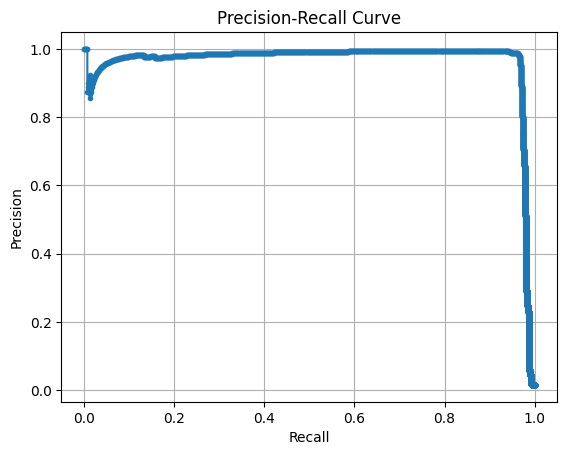

Area under ROC: 0.990
Area under PR: 0.965
F1-score: 0.967


In [ ]:
df = combined_data.drop(["V4", "V5", "V6", "V8", "V9", "V10", "V13", "V14", "V15", "V16", "V20", "V21", "V22", "V27", "Amount"], axis = 1)
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

# Preprocessing for model
scaler = preprocessing.StandardScaler().fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Test model on test
y_preds = lr_model.predict(X_test_scaled)
y_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
accuracy = metrics.accuracy_score(y_test, y_preds)
recall = metrics.recall_score(y_test, y_preds)
precision = metrics.precision_score(y_test, y_preds)
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("Recall: {:.2f}%".format(recall * 100))
print("Precision: {:.2f}%".format(precision * 100))

precision, recall, thresholds = metrics.precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs, pos_label=1)
aucpr = metrics.average_precision_score(y_test, y_probs, pos_label=1)
auc = metrics.auc(fpr, tpr)
f1_score = metrics.f1_score(y_test, y_preds)

print(f"Area under ROC: {auc:.3f}")
print(f"Area under PR: {aucpr:.3f}")
print(f"F1-score: {f1_score:.3f}")
